# curvicost in ten minutes

**What did the segmentation error actually cost?**

Overlap scores such as Dice tell you how many voxels you got right. For curvilinear structures — vessels, neurites, airways — that is rarely the question being asked. Cutting a retinal vessel tree at 10% of its branches can move under 1% of the pixels and read Dice 0.99 while about half of the reference skeleton stops being reachable. Two expert annotators can disagree at Dice 0.74 and keep 98% of it reachable.

`curvicost` puts the **metric** and the **functional cost** side by side, and generates graded, typed errors so you can see which error types your metric cannot see.

This notebook uses four vessel masks from the **FIVES** retinal dataset (CC BY 4.0; Jin *et al.*, *Sci. Data* 2022, doi:10.1038/s41597-022-01564-3), downsampled 3× so everything here runs in a few minutes on a laptop. See `data/README.md`.

Requirements: `pip install "curvicost[io]" matplotlib`.

curvicost 0.2.0.dev0
{'100_D': (682, 682), '101_G': (682, 682), '102_G': (682, 682), '103_G': (682, 682)}


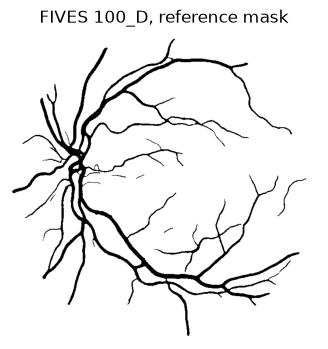

In [1]:
import glob, time, numpy as np, matplotlib.pyplot as plt
import curvicost
print("curvicost", curvicost.__version__)

masks = {p.split("/")[-1].replace("fives_", "").replace("_ds3.png", ""): curvicost.load_mask(p)[0]
         for p in sorted(glob.glob("data/fives_*_ds3.png"))}
gt = masks["100_D"]
print({k: v.shape for k, v in masks.items()})
plt.figure(figsize=(4, 4)); plt.imshow(gt, cmap="gray_r"); plt.axis("off"); plt.title("FIVES 100_D, reference mask");

## 1. Score a prediction against a reference

`score(gt, pred)` returns one flat dictionary: six metrics and the functional costs from a single pass. Scoring a mask against itself is the sanity check — everything should read 1 (or 0 for error counts).


In [2]:
row = curvicost.score(gt, gt)
for k in ("dice", "cldice", "betti0_error", "erl_frac", "traceable_frac", "conductance_frac"):
    print(f"{k:18s} {row[k]:.4f}")

dice               1.0000
cldice             1.0000
betti0_error       0.0000
erl_frac           1.0000
traceable_frac     1.0000
conductance_frac   1.0000


The two **costs** are what the biology loses:

- `traceable_frac` — *reachable length*: the fraction of the reference's skeleton voxels that lie in the prediction's connected component containing the reference root, every reference component traced from its own root. *Can I still follow it?* It is bounded by 1: a prediction cannot be more reachable than the reference, and a false connection between two reference fragments adds nothing (their voxels were already counted). `traceable_single_frac` is the same count from one pinned source.
- `conductance_frac` — the fraction of hydraulic conductance retained, from a Kirchhoff (resistor-network) solve on the prediction's own skeleton graph: unit pressure at the reference source, zero at every surviving reference terminal, resistance integrated pixel by pixel as 1/r⁴. *Does it still flow?* Thickness matters here in a way it does not for length, and adding a path can never lower it, so it can exceed 1 for a prediction thicker than the reference.


## 2. Five typed errors, and what each one costs

Each operator damages one structural property and, by construction, only that one. `severity` is a fraction of the operator's own target population (edges to break, tips to bridge, endpoints to shorten), a fraction of foreground pixels for `boundary`, and a scale factor for `radius`.

In [3]:
cases = {
    "break":    curvicost.perturb(gt, "break",    0.20, seed=0),
    "bridge":   curvicost.perturb(gt, "bridge",   0.20, seed=0),
    "truncate": curvicost.perturb(gt, "truncate", 0.20, seed=0),
    "boundary": curvicost.perturb(gt, "boundary", 0.05, seed=0),
}
# radius must be scored against its OWN scale-1.0 reconstruction (see section 3)
radius_ref, _ = curvicost.perturb(gt, "radius", 1.0)
cases["radius ×0.7"] = curvicost.perturb(gt, "radius", 0.7)

print(f"{'operator':12s} {'Dice':>7s} {'clDice':>7s} {'Betti0':>7s} {'ERL':>7s} | {'traceable':>9s} {'conduct.':>9s}")
rows = {}
for name, (pred, info) in cases.items():
    ref = radius_ref if name.startswith("radius") else gt
    r = curvicost.score(ref, pred); rows[name] = r
    print(f"{name:12s} {r['dice']:7.4f} {r['cldice']:7.4f} {r['betti0_error']:7d} {r['erl_frac']:7.3f} | "
          f"{r['traceable_frac']:9.3f} {r['conductance_frac']:9.3f}")

operator        Dice  clDice  Betti0     ERL | traceable  conduct.


break         0.9819  0.9839      17   0.235 |     0.375     0.352


bridge        0.9999  0.9999       1   0.030 |     1.000     1.000


truncate      0.9746  0.9791       0   0.920 |     0.959     0.682


boundary      0.9744  0.9927       0   0.971 |     0.986     0.672


radius ×0.7   0.8147  0.9997       0   0.999 |     0.999     0.239


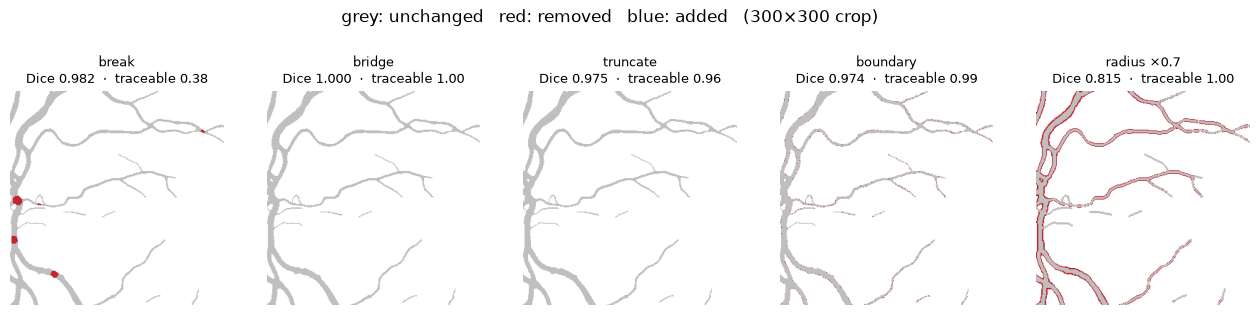

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, (name, (pred, _)) in zip(axes, cases.items()):
    ref = radius_ref if name.startswith("radius") else gt
    rgb = np.ones(gt.shape + (3,))
    rgb[ref & pred] = (0.75, 0.75, 0.75)          # unchanged
    rgb[ref & ~pred] = (0.76, 0.15, 0.18)          # removed
    rgb[~ref & pred] = (0.17, 0.42, 0.69)          # added
    ax.imshow(rgb[150:450, 150:450]); ax.set_axis_off()
    ax.set_title(f"{name}\nDice {rows[name]['dice']:.3f}  ·  traceable {rows[name]['traceable_frac']:.2f}", fontsize=9)
plt.suptitle("grey: unchanged   red: removed   blue: added   (300×300 crop)", y=1.02);

Read the table against the pictures. Two things should stand out:

- **`break`** and **`boundary`** can spend the same voxel budget for very different functional prices: connectivity errors are voxel-cheap and function-expensive. Every cut the operator reports is verified to sever the mask.
- **`bridge`** barely moves Dice or either cost — a false connection merges components (Betti-0 rises) but cannot make the reference *more* reachable and cannot lower a resistor-network conductance. A cost that an error cannot change is the wrong cost for that error: if false merges matter to you, add a merge-sensitive measure (Betti-0 error, `merged_frac`) rather than a different overlap metric.

Whether a given metric tracks a given cost depends on the error type — which is why the next tool exists.


## 3. One caveat you must respect: scoring `radius`

Rasterising a thickness change is itself lossy. If you score a radius-perturbed mask against the *original* mask, that rasterisation loss is charged to the operator and a purely geometric error looks topological. Score it against its own scale-1.0 reconstruction instead:

In [5]:
thin, _ = curvicost.perturb(gt, "radius", 0.7)
wrong = curvicost.score(gt, thin)          # original mask as reference
right = curvicost.score(radius_ref, thin)  # scale-1.0 reconstruction as reference
print(f"vs original mask:        Dice {wrong['dice']:.3f}   Betti-0 error {wrong['betti0_error']}")
print(f"vs its own reconstruction: Dice {right['dice']:.3f}   Betti-0 error {right['betti0_error']}")

vs original mask:        Dice 0.859   Betti-0 error 2
vs its own reconstruction: Dice 0.815   Betti-0 error 0


## 4. Which error types is *your* metric blind to? — `audit`

Whether a metric predicts functional cost depends on the error type, the structure class **and** the cost, so a published table for one dataset does not transfer to yours. `audit` recomputes the map on your own reference masks: it perturbs each with every operator across a severity ladder, scores every case, and correlates each metric against each cost *per operator*.

Give it at least three masks — the confidence intervals come from resampling whole masks. This runs in about a minute here.

In [6]:
import subprocess, sys
t0 = time.time()
res = subprocess.run([sys.executable, "-m", "curvicost.cli", "audit", *sorted(glob.glob("data/fives_*_ds3.png")),
                      "--csv", "blindness.csv"], capture_output=True, text=True)
print(res.stdout); print(f"[{time.time()-t0:.0f} s]")


91 cases from 4 reference mask(s)

  vs traceable length (reachable reference skeleton)
  metric              break     bridge   truncate     radius   boundary
  dice               +0.82       undef     +0.95      +0.79      +0.95 
  iou                +0.82       undef     +0.95      +0.79      +0.95 
  cldice             +0.81       undef     +1.00      +0.21*     +1.00 
  betti0_error       +0.85       undef      undef      undef      undef
  erl_frac           +0.93       undef     +1.00      +1.00      +1.00 
  diadem_like        +0.65       undef     +0.96      -0.08*     +0.56 

  vs conductance (Kirchhoff, fixed reference sinks)
  metric              break     bridge   truncate     radius   boundary
  dice               +0.87      -0.94!     +0.63      +0.76      +0.90 
  iou                +0.87      -0.94!     +0.63      +0.76      +0.90 
  cldice             +0.83      -0.96!     +0.65      -0.20*     +0.90 
  betti0_error       +0.87      -0.88!      undef      undef      

How to read it:

- `*` — the confidence interval includes zero: **that metric cannot see that error type on this data.** Report it and you report nothing about that failure mode.
- `!` — the metric **moves the wrong way**. Check first whether the *cost* is the right one for that error type.
- `undef` — the cost did not move under that operator (reachable length under `bridge`), so no correlation exists. That is a statement about the cost, not about any metric.
- Correlations are sign-aligned, so more positive always means "tracks the cost", whichever way the raw metric runs.

The full findings, with intervals, are in `blindness.csv`.

## 5. Resolution matters — the scale report

Two of `curvicost`'s parameters are absolute pixel lengths: spur pruning (`--prune-px`, default 5) and the bridge operator's search radius. The same numbers do different jobs on differently sampled data, so `audit` reports pruning in units of the structure's own vessel width and warns outside 1–4 radii.

These masks were downsampled 3× for exactly this reason: at full FIVES resolution vessels are ~6.7 px wide and 5 px is only 0.75 radii (the bridge operator then declines on every severity); at 3× they are ~2.2 px, comparable to the datasets the method was calibrated on.

In [7]:
from curvicost.audit import scale_report
for name, m in masks.items():
    r = scale_report(m, prune_px=5)
    print(f"{name}: median vessel radius {r['median_radius']:.2f} px -> 5 px = {r['prune_in_radii']:.2f} radii")
print("\nRule of thumb: stay within 1-4 radii, or pass --prune-px scaled to your data.")

100_D: median vessel radius 2.24 px -> 5 px = 2.24 radii
101_G: median vessel radius 2.00 px -> 5 px = 2.50 radii
102_G: median vessel radius 2.00 px -> 5 px = 2.50 radii
103_G: median vessel radius 3.16 px -> 5 px = 1.58 radii

Rule of thumb: stay within 1-4 radii, or pass --prune-px scaled to your data.


## 6. From the command line

```bash
curvicost score pred.tif --gt gt.tif --json row.json      # metrics + costs, one row
curvicost perturb gt.tif --operator break --severity 0.1 -o broken.tif
curvicost audit gt1.tif gt2.tif gt3.tif --csv blindness.csv
```

Scope: 2D and 3D **binary** curvilinear masks. Probability maps and multi-label images are rejected rather than silently thresholded, because the threshold changes the score and is not this tool's decision to make.

If you use `curvicost`, please cite the accompanying paper (reference to follow) and the FIVES dataset for the example data.